In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import yaml

from pydantic import BaseModel
from typing import Literal
from openai import OpenAI

def load_events(results_file: str | Path) -> pd.DataFrame:
    """Load events.jsonl file into a single DataFrame."""
    path = Path(results_file)
    frames = []
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]
    if rows:
        frames.append(pd.DataFrame(rows))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    return df

def load_all_events(results_files: list) -> pd.DataFrame:
    all_dfs = []
    for rf in results_files:
        temp_df = load_events(rf)
        all_dfs.append(temp_df)
    return pd.concat(all_dfs, ignore_index=True)


def _load_analysis_config(config: dict[str, Any] | str | Path | None) -> dict[str, Any] | None:
    if config is None or isinstance(config, dict):
        return config
    path = Path(config)
    text = path.read_text(encoding="utf-8")
    if path.suffix.lower() == ".json":
        return json.loads(text)
    return yaml.safe_load(text)


exp_name = 'promotion-discount-hidden'

def get_data(exp_name):
    results_dir = Path('/home/dw/github/toollab/results/')/exp_name
    results_files = list(results_dir.glob('*-events.jsonl'))
    config_files = list(results_dir.glob('*-config.json'))
    config_file = config_files[0] if config_files else None
    config = _load_analysis_config(config_file)
    metadata_columns = list(config['metadata'].keys())
    # print('metadata_columns', metadata_columns)

    df_raw = load_all_events(results_files)
    df = df_raw.copy().sort_values(['session_name', 'step_index'])
    meta_df = df['meta'].dropna().apply(pd.Series)
    meta_df = meta_df.add_prefix('meta_')
    if not meta_df.empty:
        df = df.join(meta_df)

    meta_cols = df.filter(like='meta_').columns
    df[meta_cols] = df.groupby('session_name')[meta_cols].ffill()
    return df, config

df, config = get_data(exp_name)
# print(f"{len(df)} events across {df['session_name'].nunique()} sessions")
# print(df[['option_count', 'design']])
print(df.columns)
print(df.shape)

print("\nNumber of sessions per condition:")

# df.groupby(['model_name', *metadata_columns])['session_name'].nunique().reset_index()

gemini_flash_lite = df[(df['model_name']=='gemini-3.1-flash-lite-preview')&(df['kind']=='tool')]
# gemini_flash_lite[['budget_type', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]


Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'budget_type', 'budget_max',
       'cumulative_cost_usd', 'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'cumulative_cost_tokens',
       'budget_remaining_tokens', 'cumulative_cost_points',
       'budget_remaining_points', 'option_count', 'option_mapping',
       'started_at', 'finished_at', 'step_index', 'kind', 'content',
       'reasoning', 'input_tokens', 'output_tokens', 'input_cost',
       'output_cost', 'tool_cost', 'point_cost', 'tool_calls', 'finish_reason',
       'meta', 'tool_name', 'tool_call_id', 'option_id', 'attribute_id',
       'result', 'is_revisit', 'transition', 'option_label',
       'meta_model_version'],
      dtype='str')
(120, 42)

Number of sessions per condition:


### Transitions

In [21]:
gemini_flash = df[(df['model_name']=='gemini-3-flash-preview')&(df['kind']=='tool')]
# gemini_lite.columns
gemini_flash[['budget_type', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]


,budget_type,budget_max,choice,step_index,option_id,attribute_id,value,transition
1,NaN,NaN,coffee_a,2,coffee_a,price_dollars,$12,first
3,NaN,NaN,coffee_a,4,coffee_b,price_dollars,$13,attribute
5,NaN,NaN,coffee_a,6,coffee_a,weight_oz,13.0 oz,diagonal
7,NaN,NaN,coffee_a,8,coffee_b,weight_oz,13.9 oz,attribute
9,NaN,NaN,coffee_a,10,coffee_a,price_cents,.99,diagonal
11,NaN,NaN,coffee_a,12,coffee_a,NaN,NaN,NaN
13,NaN,NaN,coffee_b,2,coffee_a,price_dollars,$12,first
15,NaN,NaN,coffee_b,4,coffee_a,price_cents,.99,alternative
17,NaN,NaN,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
19,NaN,NaN,coffee_b,8,coffee_b,price_dollars,$13,diagonal


In [22]:
gpt = df[(df['model_name'].str.contains('gpt'))&(df['kind']=='tool')]
# gemini_lite.columns
gpt[['model_name', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]


,model_name,budget_max,choice,step_index,option_id,attribute_id,value,transition
115,gpt-5.4-mini,5.0,coffee_b,2,coffee_a,price_dollars,$12,first
117,gpt-5.4-mini,5.0,coffee_b,4,coffee_a,price_cents,.99,alternative
119,gpt-5.4-mini,5.0,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
121,gpt-5.4-mini,5.0,coffee_b,8,coffee_b,price_dollars,$13,diagonal
123,gpt-5.4-mini,5.0,coffee_b,10,coffee_b,weight_oz,13.9 oz,alternative
125,gpt-5.4-mini,5.0,coffee_b,12,coffee_b,NaN,NaN,NaN
127,gpt-5.4,5.0,coffee_b,2,coffee_a,price_dollars,$12,first
129,gpt-5.4,5.0,coffee_b,4,coffee_a,price_cents,.99,alternative
131,gpt-5.4,5.0,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
133,gpt-5.4,5.0,coffee_b,8,coffee_b,price_dollars,$13,diagonal


In [34]:
df.columns

Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'cumulative_cost_usd',
       'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'option_count', 'seed', 'started_at',
       'finished_at', 'step_index', 'kind', 'content', 'reasoning',
       'input_tokens', 'output_tokens', 'input_cost', 'output_cost',
       'tool_cost', 'tool_calls', 'finish_reason', 'tool_name', 'tool_call_id',
       'option_id', 'attribute_id', 'value', 'turn_cost_tools', 'is_revisit',
       'transition', 'option_label', 'budget_type', 'budget_max',
       'budget_remaining_tokens', 'cumulative_cost_tokens', 'turn_cost_tokens',
       'meta', 'meta_gpt-5.4-mini-2026-03-17', 'meta_none',
       'meta_gpt-5.4-2026-03-05', 'meta_gpt-5.4-nano-2026-03-17',
       'meta_claude-sonnet-4-6', 'meta_thinking', 'meta_effort',
       'meta_model_version'],
      dtype='str')

In [35]:
df

,session_name,experiment_name,provider,model_name,forced_choice,choice,cumulative_cost_usd,budget_remaining_usd,cumulative_cost_tools,budget_remaining_tools,...,turn_cost_tokens,meta,meta_gpt-5.4-mini-2026-03-17,meta_none,meta_gpt-5.4-2026-03-05,meta_gpt-5.4-nano-2026-03-17,meta_claude-sonnet-4-6,meta_thinking,meta_effort,meta_model_version
0,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.000309,-0.000309,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.000309,-0.000309,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.001107,-0.001107,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.001107,-0.001107,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20260409T201335248464Z,left-digit,google,gemini-3-flash-preview,False,coffee_a,0.002083,-0.002083,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf
226,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,5,0,...,NaN,{'model_version': 'gemma-4-26B-A4B-it-UD-Q4_K_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf
227,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf
228,20260410T163414801115Z,left-digit,llamacpp,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf,False,coffee_b,0.000000,0.000000,5,0,...,NaN,{'model_version': 'gemma-4-26B-A4B-it-UD-Q4_K_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf


In [32]:
anthropic = df[(df['provider'].str.contains('anthropic'))&(df['kind']=='tool')]
# gemini_lite.columns
anthropic[['model_name', 'meta_thinking', 'meta_effort', 'budget_max','choice','step_index','option_id', 'attribute_id', 'value', 'transition']]


,model_name,meta_thinking,meta_effort,budget_max,choice,step_index,option_id,attribute_id,value,transition
175,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,2,coffee_a,price_dollars,$12,first
177,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,4,coffee_a,price_cents,.99,alternative
179,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,6,coffee_a,weight_oz,13.0 oz,alternative
181,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,8,coffee_b,price_dollars,$13,diagonal
183,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,10,coffee_b,weight_oz,13.9 oz,alternative
185,claude-sonnet-4-6,NaN,NaN,5.0,coffee_b,12,coffee_b,NaN,NaN,NaN
187,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,2,coffee_a,price_dollars,$12,first
189,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,4,coffee_b,price_dollars,$13,attribute
191,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,6,coffee_a,weight_oz,13.0 oz,diagonal
193,claude-sonnet-4-6,NaN,NaN,5.0,coffee_a,8,coffee_b,weight_oz,13.9 oz,attribute


In [3]:
scores = {opt['id']:opt['base_score'] for opt in config['options']}
scores

{'coffee_a': 1.00077, 'coffee_b': 1.06923}

In [4]:
# df['budget_type']

In [5]:
session_choices = df.groupby(['model_name','session_name'])['choice'].last().reset_index()
session_choices['score'] = session_choices['choice'].map(scores)
session_choices

,model_name,session_name,choice,score
0,gemini-3-flash-preview,20260409T201335248464Z,coffee_a,1.00077
1,gemini-3-flash-preview,20260409T202110975586Z,coffee_b,1.06923
2,gemini-3-flash-preview,20260409T213551363719Z,coffee_a,1.00077
3,gemini-3-flash-preview,20260409T224320378210Z,coffee_a,1.00077
4,gemini-3.1-flash-lite-preview,20260409T205849239956Z,coffee_a,1.00077
5,gemini-3.1-flash-lite-preview,20260409T205948438333Z,coffee_a,1.00077
6,gemini-3.1-flash-lite-preview,20260409T212306149951Z,coffee_a,1.00077
7,gemini-3.1-flash-lite-preview,20260409T212652870379Z,coffee_a,1.00077
8,gemini-3.1-flash-lite-preview,20260409T213049600406Z,coffee_b,1.06923
9,gemini-3.1-flash-lite-preview,20260409T213418124240Z,coffee_a,1.00077


In [6]:
(df[(df['choice']=='coffee_b')&(df['tool_name']=='inspect_cell')])[['step_index','option_id', 'attribute_id', 'value']]

,step_index,option_id,attribute_id,value
13,2,coffee_a,price_dollars,$12
15,4,coffee_a,price_cents,.99
17,6,coffee_a,weight_oz,13.0 oz
19,8,coffee_b,price_dollars,$13
21,10,coffee_b,weight_oz,13.9 oz
76,2,coffee_a,price_dollars,$12
78,4,coffee_a,price_cents,.99
80,6,coffee_a,weight_oz,13.0 oz
82,8,coffee_b,price_dollars,$13
84,10,coffee_b,price_cents,.00


In [84]:
13/12.99 # value

1.0007698229407236

In [85]:
print('worst case',13.99/13.99) # worst case
print('best case', 13.99/13.00) # best case

worst case 1.0
best case 1.0761538461538462


### Verbal protocol analysis

In [4]:
df['provider'].value_counts()

provider
google       472
llamacpp     346
mock         134
anthropic     20
Name: count, dtype: int64

In [13]:
has_reasoning  = df[(~df['reasoning'].isna()) & (df['reasoning']!='') & (df['provider']!='mock')]

has_reasoning['tc'] = has_reasoning['tool_calls'].apply(lambda l: l[0])
has_reasoning['t_name'] = has_reasoning['tc'].apply(lambda x: x.get('name'))
has_reasoning['t_option'] = has_reasoning['tc'].apply(lambda x: x.get('arguments').get('option_id'))
has_reasoning['t_attribute'] = has_reasoning['tc'].apply(lambda x: x.get('arguments').get('attribute_id'))

cue_lookup = {(c['option_id'], c['attribute_id']): c['value'] for c in config.get('cues', [])}
# Create the new value column by mapping over each row
has_reasoning['t_value'] = has_reasoning.apply(lambda row: cue_lookup.get((row['t_option'], row['t_attribute'])), axis=1)

has_reasoning[['t_name', 't_option', 't_attribute']].head()

has_reasoning[['reasoning', 'model_name']]['model_name'].value_counts()
# has_reasoning['reasoning']

model_name
gemini-3.1-pro-preview                131
gemini-3-flash-preview                105
Qwen3.5-27B-UD-Q4_K_XL.gguf            86
gemma-4-31B-it-UD-Q4_K_XL.gguf         52
gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf     22
Name: count, dtype: int64

In [15]:
has_reasoning[['t_name', 't_option', 't_attribute']]


,t_name,t_option,t_attribute
0,inspect_cell,coffee_a,price
2,inspect_cell,coffee_a,weight_oz
4,inspect_cell,coffee_b,price
6,inspect_cell,coffee_b,weight_oz
8,inspect_cell,coffee_a,list_price
...,...,...,...
942,inspect_cell,coffee_a,weight_oz
944,inspect_cell,coffee_b,weight_oz
946,inspect_cell,coffee_c,weight_oz
948,inspect_cell,coffee_a,discount_percentage


In [11]:
# has_reasoning[['step_index', 't_name', 't_option', 't_attribute', 't_value']].tail(10)

In [10]:
has_reasoning_geminipro = has_reasoning[(has_reasoning['model_name']=='gemini-3.1-pro-preview')&(has_reasoning['budget_type']=='points')]
# has_reasoning_geminipro
# for i, row in (has_reasoning_geminipro[['step_index', 'model_name','budget_type', 'budget_max', 'reasoning', 't_name', 't_option', 't_attribute', 't_value']]).iterrows():
#     print(row.to_csv())
#     print('+'*50)

### classify final reasoning

In [ ]:
client = OpenAI(
    base_url='http://localhost:8080/v1',
    api_key="sk-no-key-required"
)
class ChoiceClassification(BaseModel):
    label: Literal["price per weight value", "discount"]

def classify_reasoning(reasoning_text: str) -> str:
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary factor or attribute that drove the model's choice.\n\n"
        "Classify the reasoning into exactly one of two categories:\n"
        "1. 'price per weight value' (if the choice is based on unit price, weight-to-price ratio, or getting more product for the money)\n"
        "2. 'discount' (if the choice is based on a price reduction, sale, or percentage off the original retail price)\n\n"
        # "You must output only the exact category name and nothing else. Do not include any explanations or punctuation."
    )
    
    user_prompt = reasoning_text


    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=ChoiceClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"



In [71]:
# sample = has_reasoning_submit_choice.iloc[0]['reasoning']
# print(sample)
# classification = classify_reasoning(sample)
# print(classification)

In [68]:
has_reasoning_submit_choice = has_reasoning[has_reasoning['t_name']=='submit_choice']
has_reasoning_submit_choice['class_choice'] = has_reasoning_submit_choice['reasoning'].apply(classify_reasoning)

In [70]:
has_reasoning_submit_choice.groupby('model_name')['class_choice'].value_counts()

model_name                          class_choice          
Qwen3.5-27B-UD-Q4_K_XL.gguf         discount                   5
                                    price per weight value     4
gemini-3-flash-preview              price per weight value     8
                                    discount                   3
gemini-3.1-pro-preview              price per weight value    15
                                    discount                   7
gemma-4-26B-A4B-it-UD-Q4_K_XL.gguf  price per weight value     5
gemma-4-31B-it-UD-Q4_K_XL.gguf      price per weight value     6
                                    discount                   2
Name: count, dtype: int64

In [17]:
has_reasoning[['step_index','reasoning', 't_name']]

,step_index,reasoning,t_name
0,1,"**My Strategy for Coffee Selection**\n\nOkay, ...",inspect_cell
2,3,"Okay, here's my thought process on this:\n\n**...",inspect_cell
4,5,"Okay, here's my take on those thoughts, framed...",inspect_cell
6,7,"Okay, here's my take on those thoughts, framed...",inspect_cell
8,9,"Okay, here's my breakdown of this quick coffee...",inspect_cell
...,...,...,...
942,11,**Analyzing the Sale Price Discrepancy**\n\nOk...,inspect_cell
944,13,"Okay, here's my interpretation of that thought...",inspect_cell
946,15,"Okay, here's my interpretation of that thought...",inspect_cell
948,17,"Okay, here's my take on those thoughts, framed...",inspect_cell


# the effect of constraint on choice

### Classify choice reasoning on attribute

In [2]:
client = OpenAI(
    base_url='http://localhost:8080/v1',
    api_key="sk-no-key-required"
)
attribute_list = [att['id'] for att in config['attributes']]

class AttributeClassification(BaseModel):
    label: Literal[*attribute_list]

def classify_choice_attribute(reasoning_text: str) -> str:
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    attribute_string = ''
    for att in attribute_list:
        attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary attribute that determined the model's final choice.\n\n"
        "Classify the reasoning into exactly one of these categories:\n"
        f'{attribute_string}'
    )
    
    user_prompt = reasoning_text

    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=AttributeClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"


In [8]:
df['t_name'] = df['tool_calls'].apply(lambda l: l[0]['name'] if type(l)==list else None)
submit_choice = df[df['t_name']=='submit_choice']
submit_choice_reasoning = submit_choice[['budget_max','reasoning']].copy()
submit_choice_reasoning = submit_choice_reasoning.sort_values(by=['budget_max'], ascending=False)
sample = submit_choice_reasoning.iloc[0]
# print(sample['reasoning'])

In [9]:
submit_choice_reasoning['choice_attribute'] = None
for i, row in submit_choice_reasoning.iterrows():
    choice_attribute = classify_choice_attribute(row['reasoning'])
    submit_choice_reasoning.at[i, 'choice_attribute'] = choice_attribute
    print(row['budget_max'], choice_attribute)

20 weight_oz
20 weight_oz
20 weight_oz
10 weight_oz
10 weight_oz
10 weight_oz
10 weight_oz
10 weight_oz
10 weight_oz
10 weight_oz
10 discount_percentage
10 discount_percentage
10 weight_oz
10 weight_oz
5 weight_oz
5 sale_price
5 discount_percentage
5 sale_price
5 sale_price
5 sale_price
5 weight_oz
5 discount_percentage
5 discount_percentage
5 weight_oz
5 discount_percentage
5 discount_percentage
1 list_price
1 list_price
1 sale_price
1 sale_price
1 discount_percentage
1 discount_percentage
1 list_price
1 sale_price
1 discount_percentage
1 discount_percentage
1 discount_percentage
1 discount_percentage
1 discount_percentage
1 discount_percentage
1 discount_percentage
1 discount_percentage
1 discount_percentage
1 discount_percentage


In [10]:
submit_choice_reasoning

,budget_max,reasoning,choice_attribute
94,20,"\nThe objective is to find the ""best deal"" on ...",weight_oz
134,20,\nThe objective is to find the best deal on co...,weight_oz
58,20,\nThe objective is to find the best deal on co...,weight_oz
156,10,\nThe user wants me to find the best deal on c...,weight_oz
326,10,\nThe user wants me to find the best deal on c...,weight_oz
348,10,\nThe user wants the best deal on coffee.\nI h...,weight_oz
304,10,\nThe goal is to find the best deal on coffee....,weight_oz
282,10,\nThe user wants to find the best deal on coff...,weight_oz
238,10,\nThe goal is to find the best deal on coffee....,weight_oz
260,10,\nThe user wants to find the best deal on coff...,weight_oz


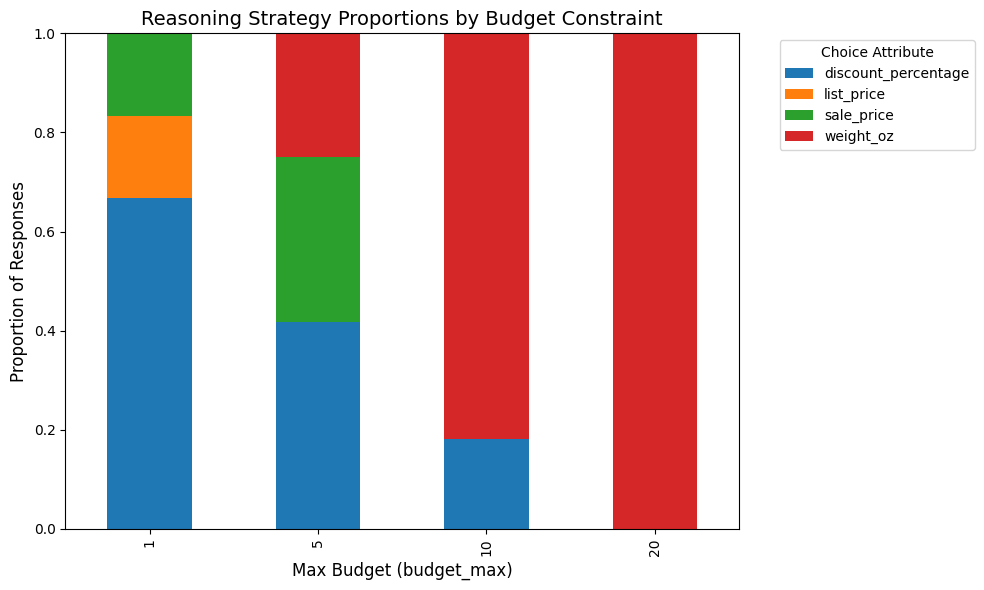

In [12]:
# 1. Create a cross-tabulation and normalize it so each row sums to 1.0 (100%)
crosstab = pd.crosstab(
    submit_choice_reasoning['budget_max'], 
    submit_choice_reasoning['choice_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

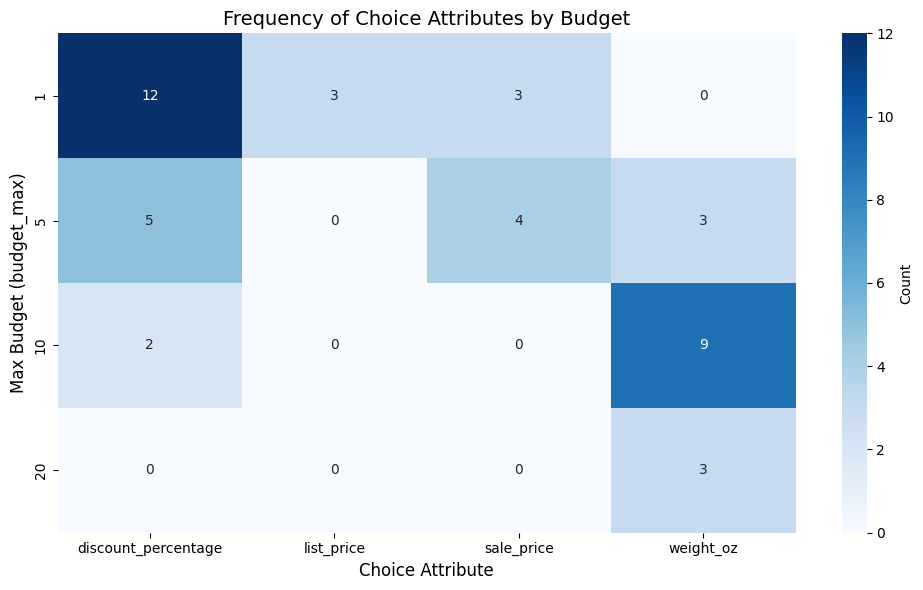

In [13]:
# 1. Get the raw counts
crosstab_counts = pd.crosstab(
    submit_choice_reasoning['budget_max'], 
    submit_choice_reasoning['choice_attribute']
)

# 2. Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_counts, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})

plt.title('Frequency of Choice Attributes by Budget', fontsize=14)
plt.ylabel('Max Budget (budget_max)', fontsize=12)
plt.xlabel('Choice Attribute', fontsize=12)
plt.tight_layout()
plt.show()

### Attributes checked

In [3]:
df, config = get_data(exp_name)

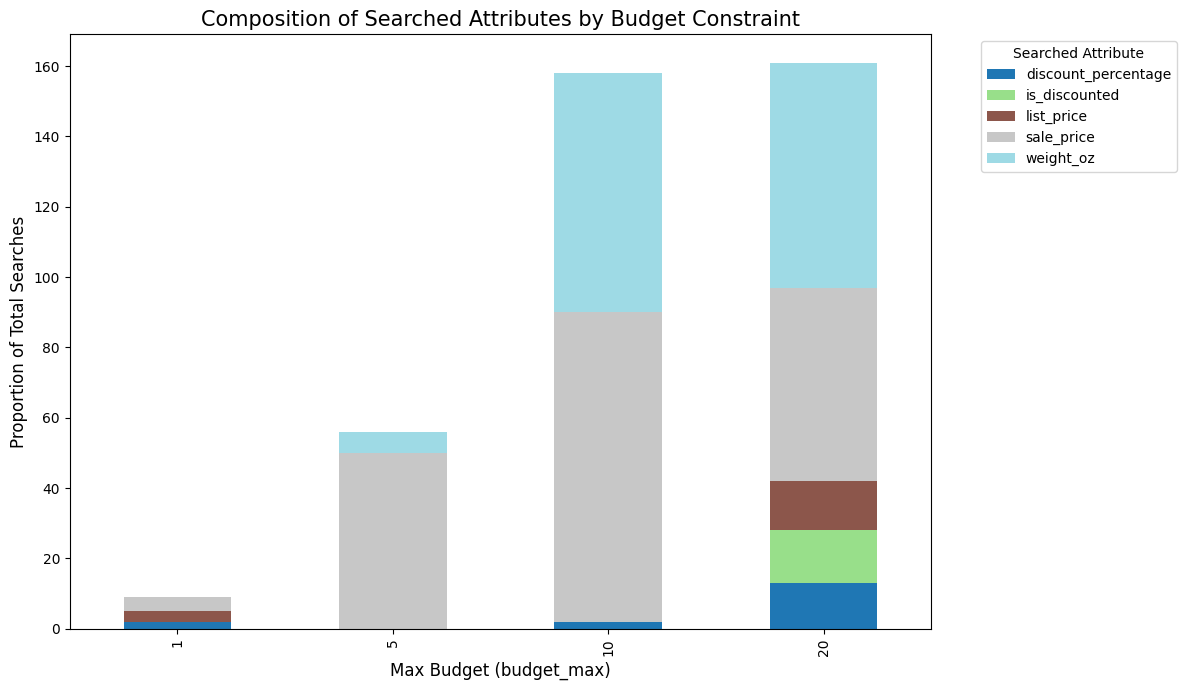

In [5]:
# 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
search_proportions = pd.crosstab(
    df['budget_max'], 
    df['attribute_id'], 
    # normalize='index' # Converts counts to percentages (0.0 to 1.0)
)

# 2. Plot as a Stacked Bar Chart
search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Total Searches', fontsize=12)
plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

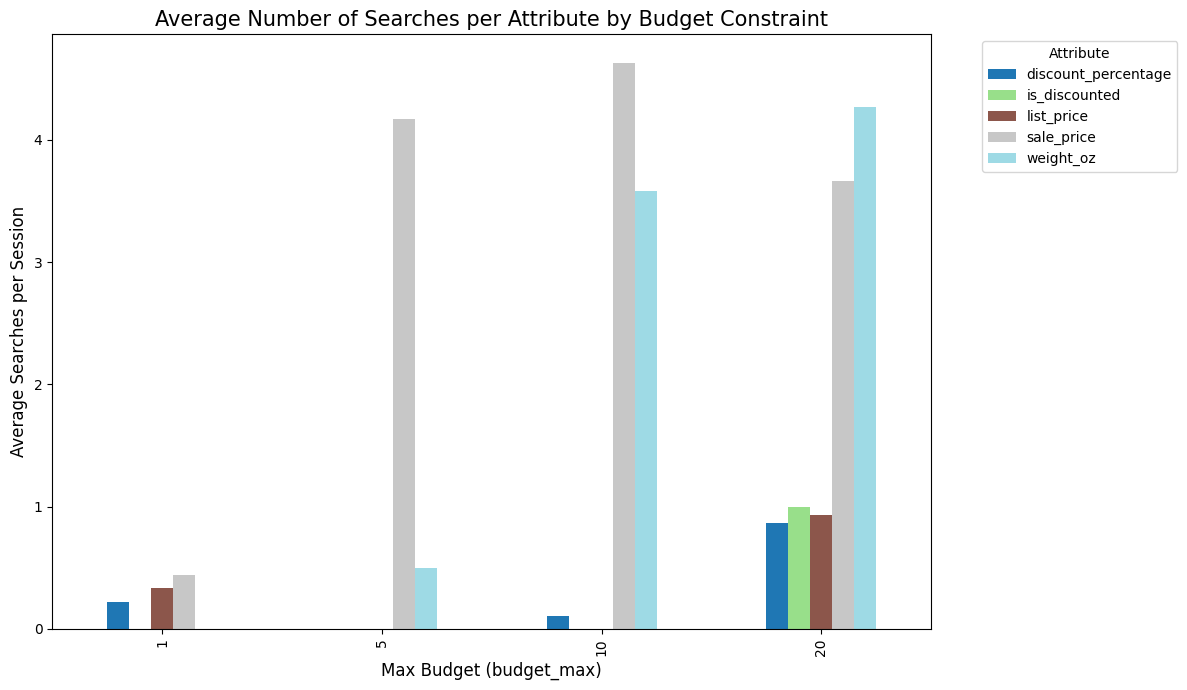

In [6]:
df_summary = (
    df.groupby(['session_name', 'budget_max'])['attribute_id']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
# 1. Using the df_summary from the previous step:
# Drop 'session_name' so we only have numbers, then group by budget and get the mean
mean_searches_per_budget = df_summary.drop(columns=['session_name']).groupby('budget_max').mean()
mean_searches_per_budget

# 2. Plot as a grouped bar chart (not stacked)
mean_searches_per_budget.plot(kind='bar', figsize=(12, 7), colormap='tab20')

plt.title('Average Number of Searches per Attribute by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Average Searches per Session', fontsize=12)
plt.legend(title='Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [8]:
df.groupby(['budget_max'])['session_name'].nunique()

budget_max
1     18
5     12
10    19
20    15
Name: session_name, dtype: int64